## Assignment-15  Clustering Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data =pd.read_excel(r'Data\EastWestAirlines.xlsx ',sheet_name=1)
data.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None


In [4]:
print(data.shape)

(3999, 12)


In [5]:
print(data.describe())

               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.360133e+04    144.114529     2.059515     1.014504   
std    1160.764358  1.007757e+05    773.663804     1.376919     0.147650   
min       1.000000  0.000000e+00      0.000000     1.000000     1.000000   
25%    1010.500000  1.852750e+04      0.000000     1.000000     1.000000   
50%    2016.000000  4.309700e+04      0.000000     1.000000     1.000000   
75%    3020.500000  9.240400e+04      0.000000     3.000000     1.000000   
max    4021.000000  1.704838e+06  11148.000000     5.000000     3.000000   

         cc3_miles    Bonus_miles  Bonus_trans  Flight_miles_12mo  \
count  3999.000000    3999.000000   3999.00000        3999.000000   
mean      1.012253   17144.846212     11.60190         460.055764   
std       0.195241   24150.967826      9.60381        1400.209171   
min       1.000000       0.000000      

In [6]:
print(data.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [7]:
# drop irrelevant columns

data = data.drop(['ID#'], axis=1, errors='ignore')
#data.head()

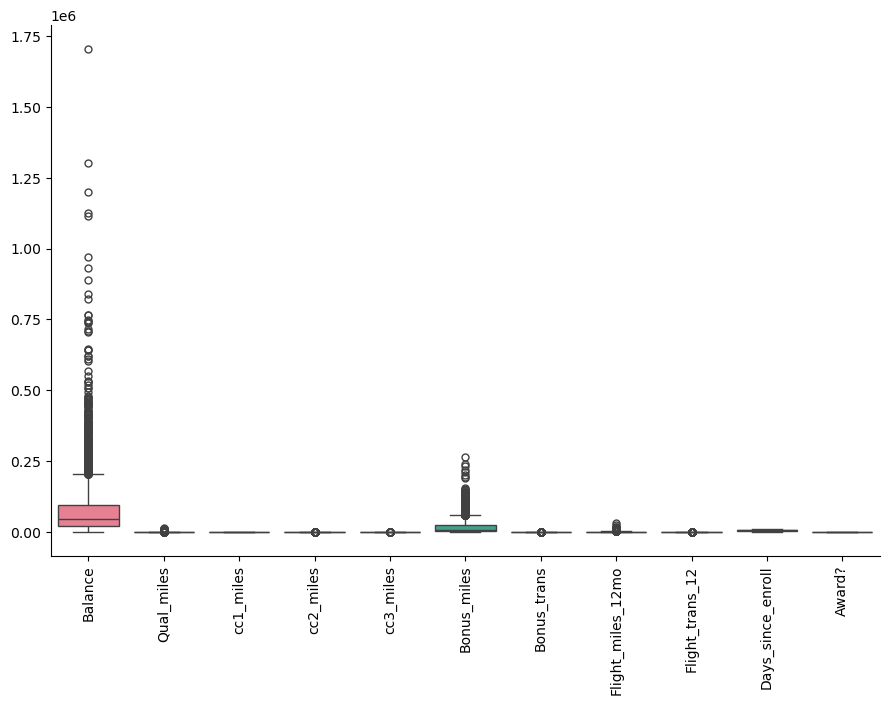

In [8]:
# Boxplot

sns.catplot(data,
           kind='box',
           height=6,
           aspect=1.5
           )
plt.xticks(rotation=90)
plt.show()

In [9]:
# removing outliers by IQR Method

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

IQR = Q3-Q1

data1 = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

In [10]:
# feature Scaling

from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data1)

##### Exploratory data analysis

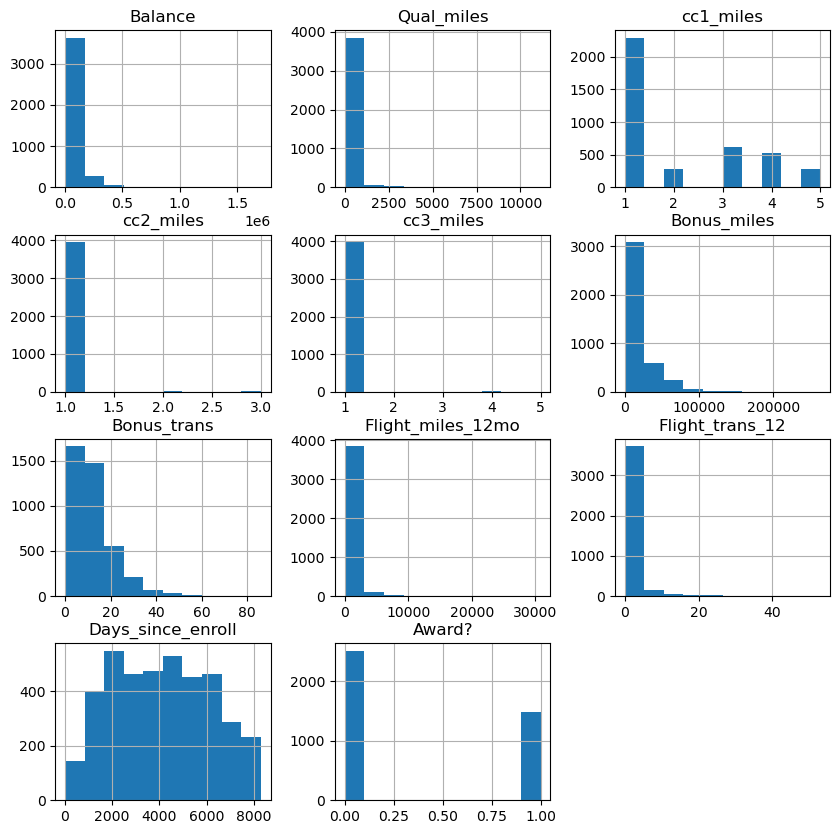

In [12]:
# Histogram

data.hist(figsize=(10,10))
plt.show()

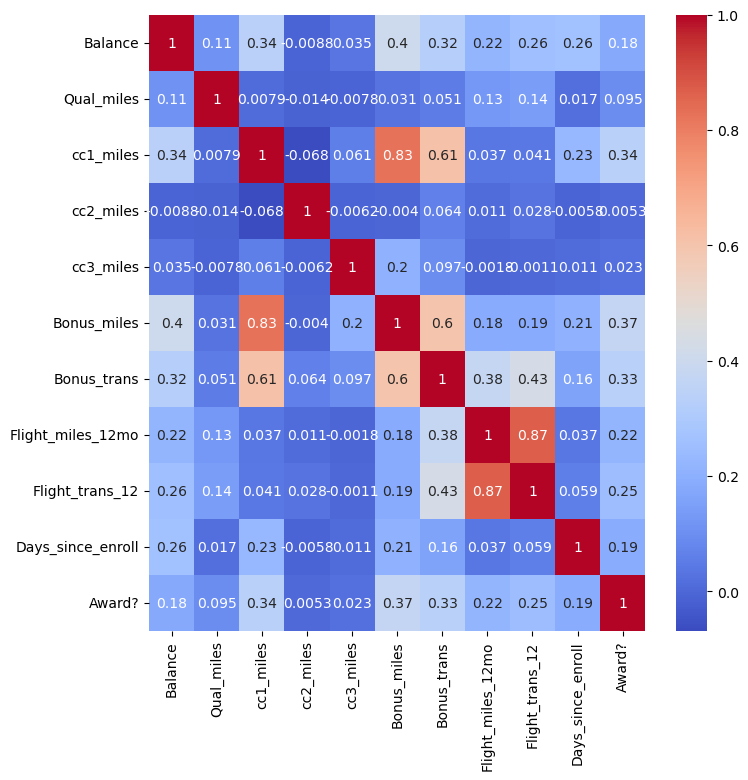

In [13]:
# Heatmap

plt.figure(figsize=(8,8))
sns.heatmap(data.corr(),
           annot=True,
           cmap='coolwarm')

plt.show()

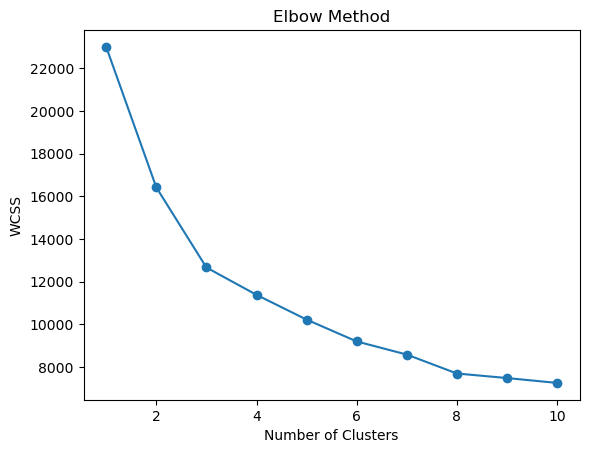

In [29]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

##### Build the model

In [36]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering


In [17]:
kmodel = KMeans(n_clusters=3)
kmodel.fit(scaled_data)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [25]:
kmodel.inertia_

12660.291391256455

In [32]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

wcss

[22999.999999999996,
 16416.789022423705,
 12660.343183196434,
 11379.380926227075,
 10218.002164653119,
 9194.244627420532,
 8578.486890331318,
 7691.265843762761,
 7478.459649790081,
 7249.845411739929]

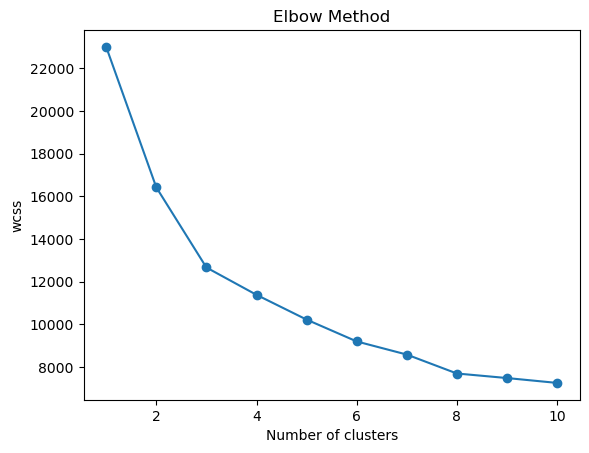

In [33]:
plt.plot(range(1,11), wcss , marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.title('Elbow Method')

plt.show()

##### Apply K Means

In [48]:
data1 = data1.copy()

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc.fit_predict(scaled_data)

data1['Hierarchical_Cluster'] = hc_labels
#data1.head()

##### silhouette_score

In [49]:
from sklearn.metrics import silhouette_score

# Apply KMeans again on correct df_scaled
kmeans = KMeans(n_clusters=4, random_state=42)
k_labels = kmeans.fit_predict(scaled_data)

# Now silhouette score will work
print("KMeans Silhouette Score:", silhouette_score(scaled_data, k_labels))

KMeans Silhouette Score: 0.22962827467448732


##### DBSCAN

###### Find Optimal ε using KNN Distance Plot

In [50]:
from sklearn.neighbors import NearestNeighbors

In [52]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)


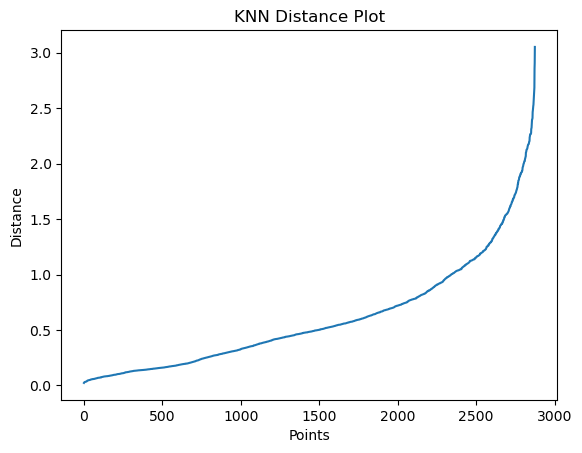

In [53]:

distances = np.sort(distances[:,4])

plt.plot(distances)
plt.title("KNN Distance Plot")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

##### Multiple ε and minPts

In [83]:
eps_values = [0.5, 1, 1.5, 2]
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for min_s in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(scaled_data)

        # Ignore noise (-1) for silhouette
        if len(set(labels)) > 1 and -1 not in set(labels):
            score = silhouette_score(scaled_data, labels)
        else:
            score = "Not valid"

        print(f"eps={eps}, min_samples={min_s}, clusters={len(set(labels))}, score={score}")

eps=0.5, min_samples=3, clusters=62, score=Not valid
eps=0.5, min_samples=5, clusters=20, score=Not valid
eps=0.5, min_samples=10, clusters=10, score=Not valid
eps=1, min_samples=3, clusters=24, score=Not valid
eps=1, min_samples=5, clusters=15, score=Not valid
eps=1, min_samples=10, clusters=4, score=Not valid
eps=1.5, min_samples=3, clusters=13, score=Not valid
eps=1.5, min_samples=5, clusters=8, score=Not valid
eps=1.5, min_samples=10, clusters=7, score=Not valid
eps=2, min_samples=3, clusters=7, score=Not valid
eps=2, min_samples=5, clusters=8, score=Not valid
eps=2, min_samples=10, clusters=6, score=Not valid


##### Final DBSCAN Model

In [96]:
data = data1.copy()   # avoid warning

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

data['DBSCAN_Cluster'] = db_labels



##### Visualizations

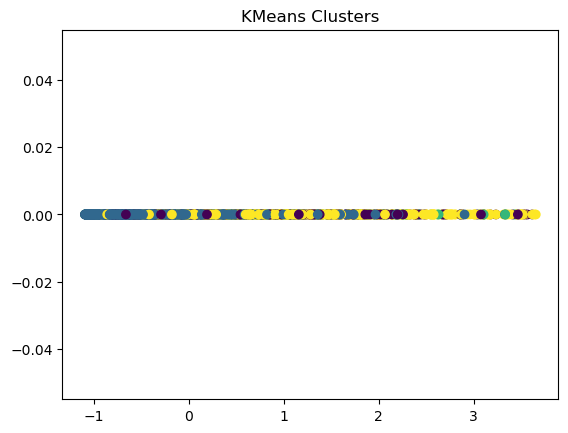

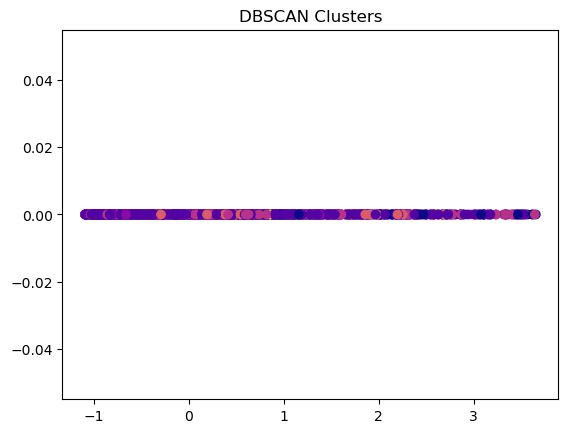

In [85]:
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=k_labels, cmap='viridis')
plt.title("KMeans Clusters")
plt.show()

plt.scatter(scaled_data[:,0], scaled_data[:,1], c=db_labels, cmap='plasma')
plt.title("DBSCAN Clusters")
plt.show()

##### HIERARCHICAL CLUSTERING

Dendrogram

In [86]:
from scipy.cluster.hierarchy import dendrogram, linkage

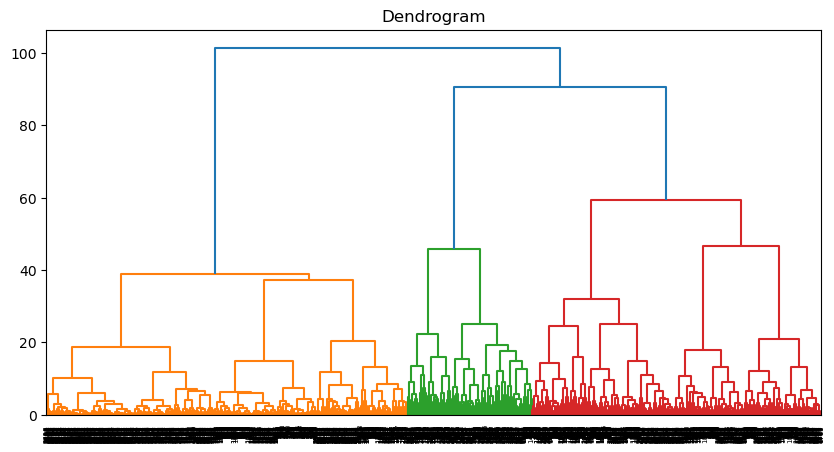

In [87]:
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

##### Appply Model

In [88]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc.fit_predict(scaled_data)

data1['Hierarchical_Cluster'] = hc_labels
#data1.head()

##### Evaluation

In [89]:
print("KMeans Silhouette Score:", silhouette_score(scaled_data, k_labels))

KMeans Silhouette Score: 0.22962827467448732


##### Visualizations

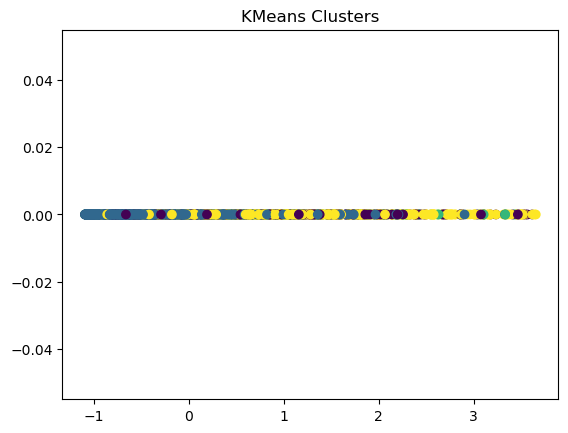

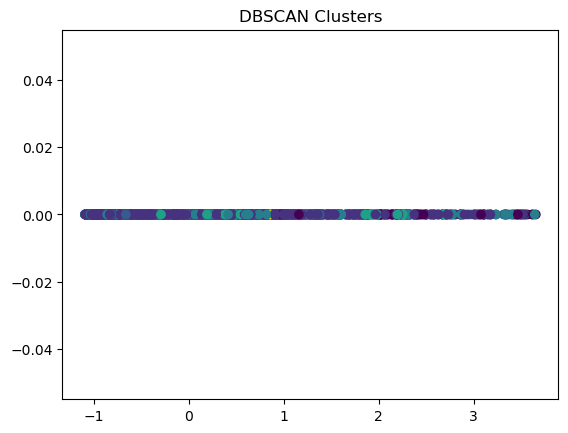

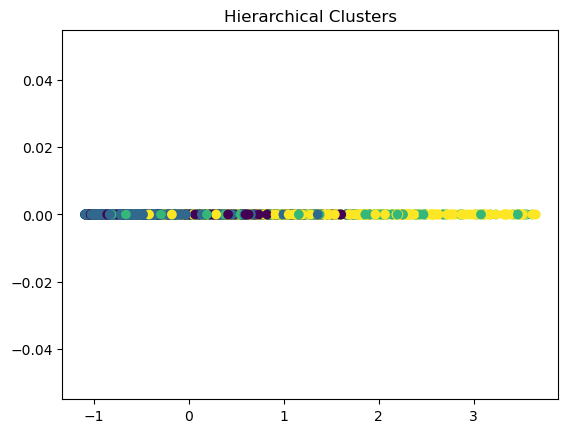

In [90]:
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=k_labels)
plt.title("KMeans Clusters")
plt.show()

plt.scatter(scaled_data[:,0], scaled_data[:,1], c=db_labels)
plt.title("DBSCAN Clusters")
plt.show()

plt.scatter(scaled_data[:,0], scaled_data[:,1], c=hc_labels)
plt.title("Hierarchical Clusters")
plt.show()

##### Cluster Analysis

###### Kmeans

In [91]:
kmeans = KMeans(n_clusters=4, random_state=42)
k_labels = kmeans.fit_predict(scaled_data)

In [92]:
data = data1.copy()  # avoid warning
data['KMeans_Cluster'] = k_labels

In [93]:
# KMeans_Cluster

print(data.groupby('KMeans_Cluster').mean())

                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                              
0               65113.991501         0.0   2.065156        1.0        1.0   
1               25552.377339         0.0   1.092516        1.0        1.0   
2               36146.795071         0.0   1.138781        1.0        1.0   
3               75069.773131         0.0   3.299113        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0               14463.011331    11.756374         428.084986         1.308782   
1                2772.070686     5.465696           4.810811         0.038462   
2                3479.610895     6.156939           4.203632         0.036316   
3               26368.466413    16.259823           6.510773         0.055767   

                Days_since_enroll    Award?  Hiera

In [97]:
# DBSCAN_Cluster

print(data['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    1805
 2     602
 3     180
 1     124
-1     115
 4      37
 5       7
 6       5
Name: count, dtype: int64


In [95]:
# Hierarchical_Cluster

print(data.groupby('Hierarchical_Cluster').mean())

                           Balance  Qual_miles  cc1_miles  cc2_miles  \
Hierarchical_Cluster                                                   
0                     36238.271062         0.0   2.391941        1.0   
1                     25586.347502         0.0   1.082774        1.0   
2                     61753.466377         0.0   2.041215        1.0   
3                     98861.707780         0.0   2.963947        1.0   

                      cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
Hierarchical_Cluster                                                            
0                           1.0  17373.097070    12.040293           0.000000   
1                           1.0   2449.995526     5.545116           0.000000   
2                           1.0  14252.574837    11.407809         355.900217   
3                           1.0  22614.958254    14.639469           0.094877   

                      Flight_trans_12  Days_since_enroll    Award?  \
Hierarchic